# Exercício 3 — Análise de pesquisas eleitorais

**Integrantes:** Andrey Salomão Almeida e Omar Habdalah Halada Saliba  
**Pergunta principal:** quão próximas as pesquisas eleitorais ficaram dos resultados reais e o que podemos aprender com os registros públicos de pesquisas no Brasil?

## 1. Introdução

O objetivo é limpar bases públicas e comparar pesquisas eleitorais com resultados reais. No final, mostramos uma pesquisa atual do Brasil.

## 2. Bases públicas utilizadas

1. [TSE — Pesquisas Eleitorais de 2014](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2014)
2. [TSE — Pesquisas Eleitorais de 2018](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2018)
3. [TSE — Pesquisas Eleitorais de 2022](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2022)
4. [TSE — Pesquisas Eleitorais de 2026](https://dadosabertos.tse.jus.br/dataset/pesquisas-eleitorais-2026)
5. [FiveThirtyEight — avaliação dos institutos](https://github.com/fivethirtyeight/data/tree/master/pollster-ratings)
6. [MIT Election Data and Science Lab — resultados eleitorais](https://electionlab.mit.edu/data)
7. [AtlasIntel/Bloomberg — pesquisa nacional de julho de 2026](https://cdn.atlasintel.org/498dd172-4381-4192-977c-c4af9787434f.pdf)

## 3. Importância da análise

Analisar pesquisas eleitorais ajuda a acompanhar mudanças na opinião dos eleitores e a verificar se as estimativas ficaram próximas dos resultados reais. A pesquisa mostra um momento da campanha, não uma certeza sobre o resultado.

## 4. Preparação do ambiente

Usaremos apenas `pandas`, `numpy`, `matplotlib` e `pathlib`.

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

RAW = Path("data/raw")
PROCESSED = Path("data/processed")
FINAL = Path("data/final")
PROCESSED.mkdir(parents=True, exist_ok=True)
FINAL.mkdir(parents=True, exist_ok=True)

## 5. Carregamento dos dados históricos

Primeiro carregamos a base e conferimos seu tamanho, colunas e valores ausentes.

In [37]:
arquivo_538 = RAW / "fivethirtyeight/raw_polls.csv"
pesquisas_brutas = pd.read_csv(arquivo_538, low_memory=False)

print("Dimensão da base bruta:", pesquisas_brutas.shape)
pesquisas_brutas.head()

Dimensão da base bruta: (20466, 30)


,poll_id,question_id,race_id,cycle,location,type_simple,race,pollster,pollster_rating_id,aapor_roper,inactive,methodology,transparency_score,partisan,polldate,electiondate,time_to_election,samplesize,cand1_name,cand1_id,cand1_party,cand1_pct,cand1_actual,cand2_name,cand2_id,cand2_party,cand2_pct,cand2_actual,margin_poll,margin_actual
0,32945,39543,1,2014,NE,Sen-G,2014_Sen-G_NE,YouGov,391,False,False,Online Panel,8.0,NaN,2014-09-26,2014-11-04,39,721.0,Dave Domina,6263,DEM,31.0,31.485351,Ben Sasse,6269,REP,58.0,64.336886,-27.0,-32.851535
1,33777,40963,1,2014,NE,Sen-G,2014_Sen-G_NE,YouGov,391,False,False,Online Panel,8.0,NaN,2014-10-20,2014-11-04,15,681.0,Dave Domina,6263,DEM,30.0,31.485351,Ben Sasse,6269,REP,59.0,64.336886,-29.0,-32.851535
2,33068,126637,2,2014,MI,Sen-G,2014_Sen-G_MI,Public Policy Polling,263,False,False,IVR/Online Panel,5.0,NaN,2014-09-06,2014-11-04,59,687.0,Gary C. Peters,6053,DEM,43.0,54.614384,Terri Lynn Land,6052,REP,36.0,41.329073,7.0,13.285311
3,33061,39666,2,2014,MI,Sen-G,2014_Sen-G_MI,Suffolk University,323,True,False,Live Phone,8.0,NaN,2014-09-08,2014-11-04,57,500.0,Gary C. Peters,6053,DEM,45.6,54.614384,Terri Lynn Land,6052,REP,36.8,41.329073,8.8,13.285311
4,33037,39642,2,2014,MI,Sen-G,2014_Sen-G_MI,Denno Research,582,False,False,Live Phone,6.0,NaN,2014-09-12,2014-11-04,53,600.0,Gary C. Peters,6053,DEM,44.7,54.614384,Terri Lynn Land,6052,REP,37.7,41.329073,7.0,13.285311


In [38]:
pesquisas_brutas.info()
print("\nDuplicatas completas:", pesquisas_brutas.duplicated().sum())
print("\nValores ausentes nas colunas principais:")
display(
    pesquisas_brutas[["pollster", "methodology", "polldate", "samplesize",
                      "cand1_pct", "cand1_actual", "cand2_pct", "cand2_actual"]]
    .isna().sum().to_frame("ausentes")
)

<class 'pandas.DataFrame'>
RangeIndex: 20466 entries, 0 to 20465
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   poll_id             20466 non-null  int64  
 1   question_id         20466 non-null  int64  
 2   race_id             20466 non-null  int64  
 3   cycle               20466 non-null  int64  
 4   location            20466 non-null  str    
 5   type_simple         20466 non-null  str    
 6   race                20466 non-null  str    
 7   pollster            20466 non-null  str    
 8   pollster_rating_id  20466 non-null  int64  
 9   aapor_roper         20466 non-null  bool   
 10  inactive            20466 non-null  bool   
 11  methodology         16915 non-null  str    
 12  transparency_score  20466 non-null  float64
 13  partisan            2556 non-null   str    
 14  polldate            20466 non-null  str    
 15  electiondate        20466 non-null  str    
 16  time_to_electio

,ausentes
pollster,0
methodology,3551
polldate,0
samplesize,0
cand1_pct,0
cand1_actual,0
cand2_pct,0
cand2_actual,0


## 6. Limpeza dos dados históricos

Selecionamos pesquisas presidenciais de 2012, 2016 e 2020 dos quatro institutos disponíveis.

In [39]:
institutos_escolhidos = ["AtlasIntel", "Ipsos", "YouGov", "Marist College"]
anos_escolhidos = [2012, 2016, 2020]

filtro = (
    pesquisas_brutas["type_simple"].eq("Pres-G")
    & pesquisas_brutas["cycle"].isin(anos_escolhidos)
    & pesquisas_brutas["pollster"].isin(institutos_escolhidos)
)

pesquisas = pesquisas_brutas.loc[filtro].copy()
pesquisas["pollster"] = pesquisas["pollster"].replace({"Marist College": "Marist"})

pesquisas["polldate"] = pd.to_datetime(pesquisas["polldate"], errors="coerce")
pesquisas["electiondate"] = pd.to_datetime(pesquisas["electiondate"], errors="coerce")

colunas_numericas = ["samplesize", "cand1_pct", "cand1_actual",
                    "cand2_pct", "cand2_actual", "margin_poll", "margin_actual"]
for coluna in colunas_numericas:
    pesquisas[coluna] = pd.to_numeric(pesquisas[coluna], errors="coerce")

duplicatas_antes = pesquisas.duplicated().sum()
pesquisas = pesquisas.drop_duplicates().copy()

pesquisas["days_to_election"] = (
    pesquisas["electiondate"] - pesquisas["polldate"]
).dt.days
pesquisas = pesquisas[pesquisas["days_to_election"] >= 0].copy()

print("Duplicatas removidas:", duplicatas_antes)
print("Dimensão após o recorte e a limpeza:", pesquisas.shape)

Duplicatas removidas: 0
Dimensão após o recorte e a limpeza: (582, 31)


Cada pesquisa possui dois candidatos na mesma linha. A seguir, separamos um candidato por linha.

In [40]:
colunas_comuns = ["poll_id", "question_id", "race", "cycle", "location",
                  "pollster", "polldate", "electiondate",
                  "days_to_election", "samplesize", "methodology"]

candidato_1 = pesquisas[colunas_comuns + ["cand1_name", "cand1_party",
                                             "cand1_pct", "cand1_actual"]].copy()
candidato_1 = candidato_1.rename(columns={
    "cand1_name": "candidate", "cand1_party": "party",
    "cand1_pct": "poll_pct", "cand1_actual": "actual_pct"
})

candidato_2 = pesquisas[colunas_comuns + ["cand2_name", "cand2_party",
                                             "cand2_pct", "cand2_actual"]].copy()
candidato_2 = candidato_2.rename(columns={
    "cand2_name": "candidate", "cand2_party": "party",
    "cand2_pct": "poll_pct", "cand2_actual": "actual_pct"
})

pesquisas_candidatos = pd.concat([candidato_1, candidato_2], ignore_index=True)
pesquisas_candidatos.head()

,poll_id,question_id,race,cycle,location,pollster,polldate,electiondate,days_to_election,samplesize,methodology,candidate,party,poll_pct,actual_pct
0,27174,24357,2012_Pres-G_US,2012,US,Ipsos,2012-09-09,2012-11-06,58,873.0,NaN,Barack Obama,DEM,48.0,50.909185
1,19108,24428,2012_Pres-G_US,2012,US,Ipsos,2012-09-11,2012-11-06,56,990.0,Online Panel,Barack Obama,DEM,48.0,50.909185
2,29391,34907,2012_Pres-G_US,2012,US,YouGov,2012-09-16,2012-11-06,51,943.0,Online Panel,Barack Obama,DEM,49.0,50.909185
3,29517,35131,2012_Pres-G_US,2012,US,Ipsos,2012-09-19,2012-11-06,48,1616.0,Online Panel,Barack Obama,DEM,48.0,50.909185
4,29598,35689,2012_Pres-G_US,2012,US,YouGov,2012-09-23,2012-11-06,44,896.0,Online Panel,Barack Obama,DEM,48.0,50.909185


### Cálculo dos erros

Erro assinado = pesquisa − resultado. O erro absoluto mostra apenas a distância em pontos percentuais.

In [41]:
pesquisas_candidatos["signed_error"] = (
    pesquisas_candidatos["poll_pct"] - pesquisas_candidatos["actual_pct"]
)
pesquisas_candidatos["absolute_error"] = pesquisas_candidatos["signed_error"].abs()
pesquisas_candidatos["source_url"] = (
    "https://github.com/fivethirtyeight/data/tree/master/pollster-ratings"
)
pesquisas_candidatos["official_result_url"] = "https://electionlab.mit.edu/data"

pesquisas["margin_error"] = pesquisas["margin_poll"] - pesquisas["margin_actual"]
pesquisas["absolute_margin_error"] = pesquisas["margin_error"].abs()
pesquisas["winner_correct"] = (
    np.sign(pesquisas["margin_poll"]) == np.sign(pesquisas["margin_actual"])
)

print("Valores ausentes após a limpeza:")
display(
    pesquisas_candidatos[["poll_pct", "actual_pct", "samplesize", "methodology"]]
    .isna().sum().to_frame("ausentes")
)

Valores ausentes após a limpeza:


,ausentes
poll_pct,0
actual_pct,0
samplesize,0
methodology,2


In [42]:
pesquisas.to_csv(PROCESSED / "polls_us_clean.csv", index=False)
pesquisas_candidatos.to_csv(PROCESSED / "polls_us_candidates.csv", index=False)
print("Arquivos históricos tratados salvos em data/processed.")

Arquivos históricos tratados salvos em data/processed.


## 7. Registros brasileiros do TSE

Reunimos os arquivos de 2014, 2018, 2022 e 2026.

In [43]:
arquivos_tse = {
    2014: RAW / "tse_pesqele/2014/pesquisa_eleitoral_2014_BR.csv",
    2018: RAW / "tse_pesqele/2018/pesquisa_eleitoral_2018_BR.csv",
    2022: RAW / "tse_pesqele/2022/pesquisa_eleitoral_2022_BR.csv",
    2026: RAW / "tse_pesqele/2026/pesquisa_eleitoral_2026_BRASIL.csv",
}

partes_tse = []
colunas_tse = [
    "AA_ELEICAO", "NR_PROTOCOLO_REGISTRO", "DT_REGISTRO",
    "NM_EMPRESA", "DS_CARGO", "DT_INICIO_PESQUISA",
    "DT_FIM_PESQUISA", "QT_ENTREVISTADO", "VR_PESQUISA",
    "DS_METODOLOGIA_PESQUISA", "DS_PLANO_AMOSTRAL", "NM_CONTRATANTE"
]

for ano, caminho in arquivos_tse.items():
    parte = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
    parte = parte.rename(columns={
        "DS_CARGOS": "DS_CARGO",
        "QT_ENTREVISTADOS": "QT_ENTREVISTADO"
    })
    for coluna in colunas_tse:
        if coluna not in parte.columns:
            parte[coluna] = np.nan
    parte = parte[colunas_tse].copy()
    parte["ano_arquivo"] = ano
    partes_tse.append(parte)

tse_bruto = pd.concat(partes_tse, ignore_index=True)
print("Dimensão dos registros reunidos:", tse_bruto.shape)
tse_bruto.head()

Dimensão dos registros reunidos: (4360, 13)


,AA_ELEICAO,NR_PROTOCOLO_REGISTRO,DT_REGISTRO,NM_EMPRESA,DS_CARGO,DT_INICIO_PESQUISA,DT_FIM_PESQUISA,QT_ENTREVISTADO,VR_PESQUISA,DS_METODOLOGIA_PESQUISA,DS_PLANO_AMOSTRAL,NM_CONTRATANTE,ano_arquivo
0,2014,BR000102014,2014-02-11 00:00:00,OPINIÃO PESQUISA ANÁLISE E CONSULTORIA LTDA,Presidente,2014-02-07 00:00:00,2014-02-13 00:00:00,500,"10000,00",Pesquisa quantitativa com aplicação de questio...,- Percentuais a serem utilizados para eventual...,NaN,2014
1,2014,BR000542014,2014-03-21 00:00:00,GK DE OLIVEIRA PRODUÇÕES ME,Presidente,2014-03-22 00:00:00,2014-03-25 00:00:00,2000,"15000,00","Pesquisa quantitativa, que consiste na realiza...","As cotas quanto a sexo, idade, escolaridade e ...",NaN,2014
2,2014,BR000532014,2014-03-21 00:00:00,IBOPE INTELIGÊNCIA PESQUISA E CONSULTORIA LTDA.,Presidente,2014-03-14 00:00:00,2014-03-17 00:00:00,2002,"214600,00","Pesquisa quantitativa, que consiste na realiza...",Representativa do eleitorado da área em estudo...,NaN,2014
3,2014,BR000632014,2014-03-31 00:00:00,"Gualberto, Orrico e Caliman Ltda",Presidente,2014-03-27 00:00:00,2014-03-28 00:00:00,400,"12000,00",Pesquisa quantitativa não probabilística com d...,A estratificação da amostra é feita com base n...,NaN,2014
4,2014,BR001022014,2014-05-02 00:00:00,Fortiori Pesquisa Diagnóstico e Marketing Ltda,Presidente,2014-05-02 00:00:00,2014-05-06 00:00:00,1000,"20000,00",A pesquisa da Fortiori é uma pesquisa quantita...,Tamanho da amostra  1000 entrevistas Sexo Ho...,NaN,2014


In [44]:
tse_bruto.info()
print("\nDuplicatas completas:", tse_bruto.duplicated().sum())
print("Protocolos repetidos:", tse_bruto["NR_PROTOCOLO_REGISTRO"].duplicated().sum())
display(tse_bruto.isna().sum().to_frame("ausentes"))

<class 'pandas.DataFrame'>
RangeIndex: 4360 entries, 0 to 4359
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   AA_ELEICAO               4360 non-null   int64 
 1   NR_PROTOCOLO_REGISTRO    4360 non-null   str   
 2   DT_REGISTRO              4360 non-null   str   
 3   NM_EMPRESA               4360 non-null   str   
 4   DS_CARGO                 4360 non-null   str   
 5   DT_INICIO_PESQUISA       4360 non-null   str   
 6   DT_FIM_PESQUISA          4360 non-null   str   
 7   QT_ENTREVISTADO          4360 non-null   int64 
 8   VR_PESQUISA              4360 non-null   str   
 9   DS_METODOLOGIA_PESQUISA  4360 non-null   str   
 10  DS_PLANO_AMOSTRAL        4360 non-null   str   
 11  NM_CONTRATANTE           714 non-null    object
 12  ano_arquivo              4360 non-null   int64 
dtypes: int64(3), object(1), str(9)
memory usage: 442.9+ KB

Duplicatas completas: 0
Protocolos repetidos: 58

,ausentes
AA_ELEICAO,0
NR_PROTOCOLO_REGISTRO,0
DT_REGISTRO,0
NM_EMPRESA,0
DS_CARGO,0
DT_INICIO_PESQUISA,0
DT_FIM_PESQUISA,0
QT_ENTREVISTADO,0
VR_PESQUISA,0
DS_METODOLOGIA_PESQUISA,0


## 8. Limpeza dos dados do TSE

Padronizamos nomes, datas, valores e removemos protocolos repetidos.

In [45]:
tse = tse_bruto[
    tse_bruto["DS_CARGO"].astype(str).str.contains("Presidente", case=False, na=False)
].copy()

tse["instituto_original"] = (
    tse["NM_EMPRESA"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
)
tse["instituto"] = tse["instituto_original"]

maiusculo = tse["instituto_original"].str.upper()
tse.loc[maiusculo.str.contains("ATLASINTEL", na=False), "instituto"] = "AtlasIntel"
tse.loc[maiusculo.str.contains("IBOPE", na=False), "instituto"] = "IBOPE"
tse.loc[
    maiusculo.str.contains("IPEC", na=False)
    | maiusculo.eq("INTELIGENCIA EM PESQUISA E CONSULTORIA LTDA"),
    "instituto"
] = "Ipec"

for coluna in ["DT_REGISTRO", "DT_INICIO_PESQUISA", "DT_FIM_PESQUISA"]:
    tse[coluna] = pd.to_datetime(
        tse[coluna], format="mixed", dayfirst=True, errors="coerce"
    )

tse["QT_ENTREVISTADO"] = pd.to_numeric(tse["QT_ENTREVISTADO"], errors="coerce")
tse.loc[tse["QT_ENTREVISTADO"] <= 0, "QT_ENTREVISTADO"] = np.nan
tse["VR_PESQUISA"] = pd.to_numeric(
    tse["VR_PESQUISA"].astype(str).str.replace(".", "", regex=False)
                              .str.replace(",", ".", regex=False),
    errors="coerce"
)

tse["duracao_coleta_dias"] = (
    tse["DT_FIM_PESQUISA"] - tse["DT_INICIO_PESQUISA"]
).dt.days + 1

duplicatas_protocolo = tse["NR_PROTOCOLO_REGISTRO"].duplicated().sum()
tse = tse.drop_duplicates(subset="NR_PROTOCOLO_REGISTRO").copy()
print("Protocolos repetidos removidos:", duplicatas_protocolo)
print("Dimensão da base limpa do TSE:", tse.shape)

Protocolos repetidos removidos: 58
Dimensão da base limpa do TSE: (3359, 16)


A metodologia foi agrupada em categorias simples usando palavras do texto original.

In [46]:
texto_metodo = tse["DS_METODOLOGIA_PESQUISA"].fillna("").str.lower()

online = texto_metodo.str.contains("online|internet|digital")
telefone = texto_metodo.str.contains("telefone|telefônica|telefonica")
presencial = texto_metodo.str.contains("presencial|domicílio|domicilio|pessoal")
misto = online.astype(int) + telefone.astype(int) + presencial.astype(int) > 1

tse["metodologia_resumida"] = np.select(
    [misto, online, telefone, presencial],
    ["Misto", "Online/digital", "Telefone", "Presencial"],
    default="Não identificado",
)

tse.to_csv(PROCESSED / "tse_pesquisas_presidente_clean.csv", index=False)
tse[["ano_arquivo", "instituto", "QT_ENTREVISTADO", "metodologia_resumida"]].head()

,ano_arquivo,instituto,QT_ENTREVISTADO,metodologia_resumida
0,2014,OPINIÃO PESQUISA ANÁLISE E CONSULTORIA LTDA,500.0,Não identificado
1,2014,GK DE OLIVEIRA PRODUÇÕES ME,2000.0,Não identificado
2,2014,IBOPE,2002.0,Não identificado
3,2014,"Gualberto, Orrico e Caliman Ltda",400.0,Não identificado
4,2014,Fortiori Pesquisa Diagnóstico e Marketing Ltda,1000.0,Não identificado


## 9. Estatística descritiva dos registros brasileiros

Calculamos medidas simples e comparamos os anos.

In [47]:
tse[["QT_ENTREVISTADO", "VR_PESQUISA", "duracao_coleta_dias"]].describe().round(2)

,QT_ENTREVISTADO,VR_PESQUISA,duracao_coleta_dias
count,3358.00,3359.00,3359.00
mean,1674.94,65690.09,413.48
std,2302.19,91156.94,17009.06
min,3.00,0.00,-262.00
25%,850.00,17500.00,2.00
50%,1257.00,40000.00,4.00
75%,2000.00,85598.48,7.00
max,64200.00,3118500.00,730400.00


In [48]:
resumo_tse_ano = (
    tse.groupby("ano_arquivo")
       .agg(
           pesquisas_registradas=("NR_PROTOCOLO_REGISTRO", "nunique"),
           amostra_media=("QT_ENTREVISTADO", "mean"),
           amostra_mediana=("QT_ENTREVISTADO", "median"),
           custo_mediano=("VR_PESQUISA", "median"),
           duracao_media=("duracao_coleta_dias", "mean"),
       )
       .round(2)
)
resumo_tse_ano

,pesquisas_registradas,amostra_media,amostra_mediana,custo_mediano,duracao_media
ano_arquivo,,,,,
2014,931,1549.20,1100.0,36000.0,1487.57
2018,657,1713.68,1200.0,42000.0,4.54
2022,1191,1778.18,1512.0,39780.0,-4.29
2026,580,1620.80,1500.0,50000.0,10.50


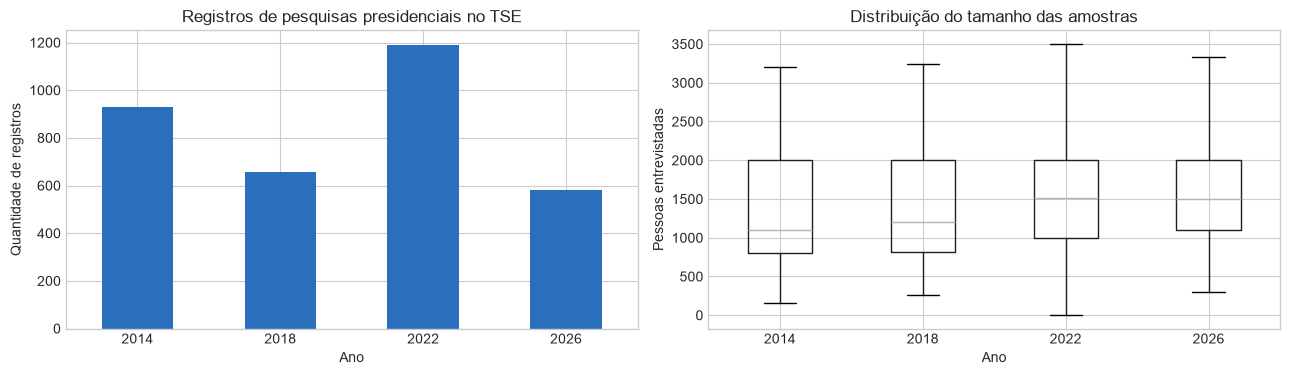

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumo_tse_ano["pesquisas_registradas"].plot(
    kind="bar", ax=axes[0], color="#2a6fbb"
)
axes[0].set_title("Registros de pesquisas presidenciais no TSE")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade de registros")
axes[0].tick_params(axis="x", rotation=0)

tse.boxplot(column="QT_ENTREVISTADO", by="ano_arquivo", ax=axes[1], showfliers=False)
axes[1].set_title("Distribuição do tamanho das amostras")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Pessoas entrevistadas")
plt.suptitle("")
plt.tight_layout()
plt.show()

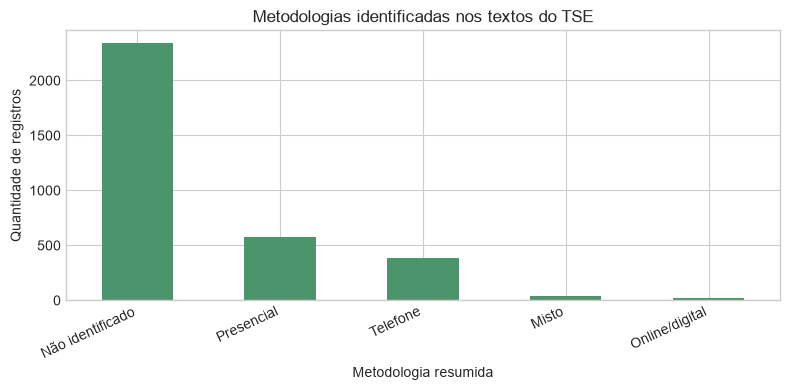

In [50]:
metodologias = tse["metodologia_resumida"].value_counts()
metodologias.plot(kind="bar", figsize=(8, 4), color="#4c956c")
plt.title("Metodologias identificadas nos textos do TSE")
plt.xlabel("Metodologia resumida")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [51]:
foco_brasil = tse[tse["instituto"].isin(["AtlasIntel", "IBOPE", "Ipec"])]
tabela_foco_brasil = pd.crosstab(foco_brasil["instituto"], foco_brasil["ano_arquivo"])
tabela_foco_brasil

ano_arquivo,2014,2018,2022,2026
instituto,,,,
AtlasIntel,0,0,86,24
IBOPE,201,171,0,0
Ipec,2,0,143,3


## 10. Análise descritiva consolidada

Resumo dos dados históricos disponíveis para análise.

In [64]:
# Resumo descritivo dos dados dos EUA
print("=" * 70)
print("DADOS HISTÓRICOS — FIVETHIRTYEIGHT")
print("=" * 70)
print(f"Período: {pesquisas['cycle'].min():.0f} a {pesquisas['cycle'].max():.0f}")
print(f"Total de pesquisas: {pesquisas.shape[0]}")
print(f"Total de observações (candidatos): {pesquisas_candidatos.shape[0]}")
print(f"Institutos: {', '.join(sorted(pesquisas['pollster'].unique()))}")

# Distribuição por instituto
print("\nDistribuição por instituto:")
dist_inst = pesquisas_candidatos['pollster'].value_counts()
for inst, qtd in dist_inst.items():
    print(f"  {inst}: {qtd} observações")

# Estatísticas de erro
print(f"\nErro absoluto (MAE): {pesquisas_candidatos['absolute_error'].mean():.2f} pp")
print(f"Erro mediano: {pesquisas_candidatos['absolute_error'].median():.2f} pp")
print(f"Erro máximo: {pesquisas_candidatos['absolute_error'].max():.2f} pp")
print(f"\nViés médio: {pesquisas_candidatos['signed_error'].mean():.2f} pp")
print(f"\nAmostra média: {pesquisas['samplesize'].mean():.0f} respondentes")

DADOS HISTÓRICOS — FIVETHIRTYEIGHT
Período: 2012 a 2020
Total de pesquisas: 582
Total de observações (candidatos): 1164
Institutos: AtlasIntel, Ipsos, Marist, YouGov

Distribuição por instituto:
  Ipsos: 580 observações
  YouGov: 466 observações
  Marist: 98 observações
  AtlasIntel: 20 observações

Erro absoluto (MAE): 3.95 pp
Erro mediano: 3.17 pp
Erro máximo: 18.16 pp

Viés médio: -3.24 pp

Amostra média: 1173 respondentes


## 11. Análise específica: AtlasIntel

A AtlasIntel participa apenas das eleições de 2020 (EUA) e 2022-2026 (Brasil).

### Desempenho da AtlasIntel nos EUA (2020)

In [65]:
# Filtrar dados da AtlasIntel nos EUA
atlas_us = pesquisas_candidatos[pesquisas_candidatos['pollster'] == 'AtlasIntel'].copy()

print(f"Observações da AtlasIntel (EUA): {atlas_us.shape[0]}")
print(f"MAE: {atlas_us['absolute_error'].mean():.2f} pp")
print(f"Viés: {atlas_us['signed_error'].mean():.2f} pp")
print(f"Distância média até eleição: {atlas_us['days_to_election'].mean():.1f} dias")

# Análise por faixa de distância (dados limitados em 2020)
print("\nDistribuição por distância até eleição:")
print(atlas_us[['days_to_election', 'poll_pct', 'actual_pct', 'signed_error']].describe().round(2))

Observações da AtlasIntel (EUA): 20
MAE: 1.37 pp
Viés: -0.76 pp
Distância média até eleição: 4.7 dias

Distribuição por distância até eleição:
       days_to_election  poll_pct  actual_pct  signed_error
count             20.00     20.00       20.00         20.00
mean               4.70     48.50       49.26         -0.76
std                1.03      1.56        1.91          1.48
min                4.00     45.90       45.24         -3.37
25%                4.00     47.45       48.41         -1.97
50%                4.00     48.50       49.30         -0.70
75%                5.00     49.70       50.16          0.74
max                7.00     50.90       53.27          1.34


### Análise da AtlasIntel no Brasil (TSE)

In [66]:
# Filtrar dados da AtlasIntel no Brasil
atlas_br = tse[tse['instituto'] == 'AtlasIntel'].copy()

print(f"Observações da AtlasIntel (Brasil): {atlas_br.shape[0]}")
print(f"Anos: {', '.join(map(str, sorted(atlas_br['ano_arquivo'].unique())))}")
print(f"\nDistribuição por ano:")
print(atlas_br['ano_arquivo'].value_counts().sort_index())

print(f"\nAmostra:")
print(f"  Média: {atlas_br['QT_ENTREVISTADO'].mean():.0f} respondentes")
print(f"  Mediana: {atlas_br['QT_ENTREVISTADO'].median():.0f} respondentes")
print(f"  Intervalo: {atlas_br['QT_ENTREVISTADO'].min():.0f} a {atlas_br['QT_ENTREVISTADO'].max():.0f}")

print(f"\nMetodologias identificadas:")
print(atlas_br['metodologia_resumida'].value_counts())

Observações da AtlasIntel (Brasil): 110
Anos: 2022, 2026

Distribuição por ano:
ano_arquivo
2022    86
2026    24
Name: count, dtype: int64

Amostra:
  Média: 2370 respondentes
  Mediana: 1600 respondentes
  Intervalo: 800 a 7500

Metodologias identificadas:
metodologia_resumida
Não identificado    110
Name: count, dtype: int64


## 12. Pesquisa atual de 2026

Aplicamos o comportamento histórico da AtlasIntel para contextualizar a pesquisa atual.

In [68]:
# Carregar pesquisa atual
pesquisa_atual = pd.read_csv(PROCESSED / "pesquisa_atual_atlas_julho_2026.csv")

print("AtlasIntel/Bloomberg — 1º turno — Julho de 2026")
print("(" + "5.021 entrevistados, 22-27 de julho, margem de erro ±1 pp, Registro TSE BR-08602/2026" + ")")
print(pesquisa_atual.to_string(index=False))

print(f"\nTotal: {pesquisa_atual['percentual'].sum():.1f}%")

AtlasIntel/Bloomberg — 1º turno — Julho de 2026
(5.021 entrevistados, 22-27 de julho, margem de erro ±1 pp, Registro TSE BR-08602/2026)
       candidato  percentual
            Lula        44.9
Flávio Bolsonaro        35.8
    Renan Santos         7.8
  Ronaldo Caiado         3.1
      Romeu Zema         2.8
  Samara Martins         2.1
    Augusto Cury         1.6

Total: 98.1%


### Aplicação do viés histórico à pesquisa atual

Aplicamos o viés histórico observado da AtlasIntel para ajustar a pesquisa atual.

**Viés histórico da AtlasIntel (EUA 2020):** -0.76 pp
- Isto é: AtlasIntel tendeu a subestimar (pesquisa ≈ resultado − 0.76 pp)

**Fórmula:**
- Projeção = percentual atual − viés = percentual atual − (−0.76) = percentual atual + 0.76 pp

In [69]:
# Calcular projeção aplicando viés histórico
vies_atlas_us = atlas_us['signed_error'].mean()
print(f"Viés histórico da AtlasIntel (EUA 2020): {vies_atlas_us:.2f} pp")

pesquisa_atual['projetado'] = pesquisa_atual['percentual'] - vies_atlas_us

print("\nComparação: Pesquisa Atual × Projeção (corrigida pelo viés histórico)")
resultado_tabela = pesquisa_atual[['candidato', 'percentual', 'projetado']].copy()
resultado_tabela['diferença'] = resultado_tabela['projetado'] - resultado_tabela['percentual']
resultado_tabela.columns = ['Candidato', 'Pesquisa (%)', 'Projeção (%)', 'Ajuste (pp)']
print(resultado_tabela.to_string(index=False))

# Validar que totais estão coerentes
print(f"\nSoma pesquisa: {pesquisa_atual['percentual'].sum():.1f}%")
print(f"Soma projeção: {pesquisa_atual['projetado'].sum():.1f}%")

Viés histórico da AtlasIntel (EUA 2020): -0.76 pp

Comparação: Pesquisa Atual × Projeção (corrigida pelo viés histórico)
       Candidato  Pesquisa (%)  Projeção (%)  Ajuste (pp)
            Lula          44.9     45.660108     0.760108
Flávio Bolsonaro          35.8     36.560108     0.760108
    Renan Santos           7.8      8.560108     0.760108
  Ronaldo Caiado           3.1      3.860108     0.760108
      Romeu Zema           2.8      3.560108     0.760108
  Samara Martins           2.1      2.860108     0.760108
    Augusto Cury           1.6      2.360108     0.760108

Soma pesquisa: 98.1%
Soma projeção: 103.4%


## 13. Visualização: Pesquisa vs Projeção

Gráfico comparativo dos valores atuais com a projeção ajustada.

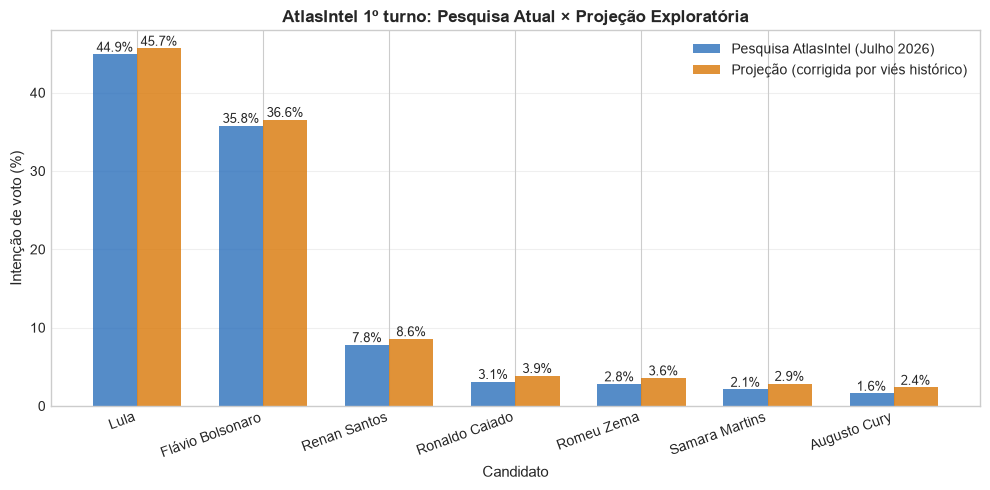

Nota: A projeção é uma simulação baseada no viés histórico da AtlasIntel em 2020,
não uma previsão certa do resultado eleitoral de 2026.


In [70]:
# Gráfico de comparação
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(pesquisa_atual))
width = 0.35

bars1 = ax.bar(x - width/2, pesquisa_atual['percentual'], width, 
               label='Pesquisa AtlasIntel (Julho 2026)', color='#2a6fbb', alpha=0.8)
bars2 = ax.bar(x + width/2, pesquisa_atual['projetado'], width,
               label='Projeção (corrigida por viés histórico)', color='#d97706', alpha=0.8)

ax.set_xlabel('Candidato', fontsize=11)
ax.set_ylabel('Intenção de voto (%)', fontsize=11)
ax.set_title('AtlasIntel 1º turno: Pesquisa Atual × Projeção Exploratória', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pesquisa_atual['candidato'], rotation=20, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Nota: A projeção é uma simulação baseada no viés histórico da AtlasIntel em 2020,")
print(f"não uma previsão certa do resultado eleitoral de 2026.")

## 14. Simulação de primeiro turno

Resumo da projeção: candidatos, posições e margens.

In [83]:
# Simulação de primeiro turno
simulacao_1t = pesquisa_atual[['candidato', 'projetado']].copy()
simulacao_1t = simulacao_1t.sort_values('projetado', ascending=False).reset_index(drop=True)
simulacao_1t.columns = ['Candidato', 'Projeção (%)']
simulacao_1t['Posição'] = range(1, len(simulacao_1t) + 1)
simulacao_1t = simulacao_1t[['Posição', 'Candidato', 'Projeção (%)']]

print("SIMULAÇÃO DE PRIMEIRO TURNO")
print("=" * 60)
print(simulacao_1t.to_string(index=False))
print(f"\nTotal: {simulacao_1t['Projeção (%)'].sum():.1f}%")

# Top 2 para possível segundo turno
top_2 = simulacao_1t.head(2)
print(f"\nMaiores votações: {top_2.iloc[0]['Candidato']} e {top_2.iloc[1]['Candidato']}")


print(f"\nO total sair acima de 100% é esperado e legítimo por causa de como a correção de viés funciona. \nEla não 'normaliza' o total, só aplica um ajuste sistemático baseado no comportamento histórico.")

SIMULAÇÃO DE PRIMEIRO TURNO
 Posição        Candidato  Projeção (%)
       1             Lula     45.660108
       2 Flávio Bolsonaro     36.560108
       3     Renan Santos      8.560108
       4   Ronaldo Caiado      3.860108
       5       Romeu Zema      3.560108
       6   Samara Martins      2.860108
       7     Augusto Cury      2.360108

Total: 103.4%

Maiores votações: Lula e Flávio Bolsonaro

O total sair acima de 100% é esperado e legítimo por causa de como a correção de viés funciona. 
Ela não 'normaliza' o total, só aplica um ajuste sistemático baseado no comportamento histórico.


## 15. Viés histórico por instituto

Análise do viés médio (tendência de superestimar ou subestimar) de cada instituto.

In [72]:
# Viés por instituto
print("\nVIÉS HISTÓRICO POR INSTITUTO")
print("=" * 70)
print("(Positivo = tende a superestimar | Negativo = tende a subestimar)\n")

vies_por_inst = pesquisas_candidatos.groupby('pollster')['signed_error'].agg([
    ('n', 'count'),
    ('viés_médio', 'mean'),
    ('desvio', 'std'),
    ('MAE', lambda x: x.abs().mean())
]).round(2)

vies_por_inst = vies_por_inst.sort_values('viés_médio')
print(vies_por_inst.to_string())

print("\nInterpretação:")
print("- A tendência do erro (viés) mostra se o instituto historicamente superestima ou subestima")
print("- Um viés de -0.76 pp significa que a pesquisa tende a ficar 0.76 pp abaixo do resultado")
print("- MAE (Erro Absoluto Médio) mede o tamanho típico do erro, independente de direção")


VIÉS HISTÓRICO POR INSTITUTO
(Positivo = tende a superestimar | Negativo = tende a subestimar)

              n  viés_médio  desvio   MAE
pollster                                 
Ipsos       580       -3.40    4.12  4.28
YouGov      466       -3.33    3.70  3.84
Marist       98       -2.35    2.91  3.02
AtlasIntel   20       -0.76    1.48  1.37

Interpretação:
- A tendência do erro (viés) mostra se o instituto historicamente superestima ou subestima
- Um viés de -0.76 pp significa que a pesquisa tende a ficar 0.76 pp abaixo do resultado
- MAE (Erro Absoluto Médio) mede o tamanho típico do erro, independente de direção


## 16. Erro conforme a distância até a eleição

Análise de como o erro varia conforme a eleição se aproxima (dados dos EUA).

In [73]:
# Erro por distância até eleição
print("\nERRO ABSOLUTO POR DISTÂNCIA ATÉ A ELEIÇÃO")
print("=" * 70 + "\n")

# Criar faixas de distância
faixas_dist = [0, 7, 14, 21, 30, 60, 999]
labels_dist = ["0-7 dias", "8-14 dias", "15-21 dias", "22-30 dias", "31-60 dias", "61+ dias"]

pesquisas_candidatos['faixa_dist'] = pd.cut(
    pesquisas_candidatos['days_to_election'],
    bins=faixas_dist,
    labels=labels_dist
)

erro_dist = pesquisas_candidatos.groupby('faixa_dist', observed=True).agg({
    'absolute_error': ['count', 'mean', 'median', 'std'],
    'signed_error': 'mean'
}).round(2)

erro_dist.columns = ['n', 'MAE', 'MAE_mediano', 'desvio', 'viés']
print(erro_dist.to_string())

print("\nOBSERVAÇÃO:")
print("- Proximidade da eleição pode reduzir erro (mais dados reais disponíveis)")
print("- Ou pode aumentá-lo (incerteza sobre possíveis mudanças no último momento)")
print("- Padrão depende dos dados específicos e contexto de cada eleição")


ERRO ABSOLUTO POR DISTÂNCIA ATÉ A ELEIÇÃO

              n   MAE  MAE_mediano  desvio  viés
faixa_dist                                      
0-7 dias    178  2.51         2.38    1.80 -1.95
8-14 dias   146  3.82         3.23    2.77 -2.75
15-21 dias  206  5.02         4.21    3.81 -4.56
22-30 dias  198  3.88         2.93    3.19 -2.85
31-60 dias  428  4.11         3.59    3.05 -3.47
61+ dias      8  3.63         4.13    2.68 -3.56

OBSERVAÇÃO:
- Proximidade da eleição pode reduzir erro (mais dados reais disponíveis)
- Ou pode aumentá-lo (incerteza sobre possíveis mudanças no último momento)
- Padrão depende dos dados específicos e contexto de cada eleição


## 17. Gráfico: Erro por distância até eleição

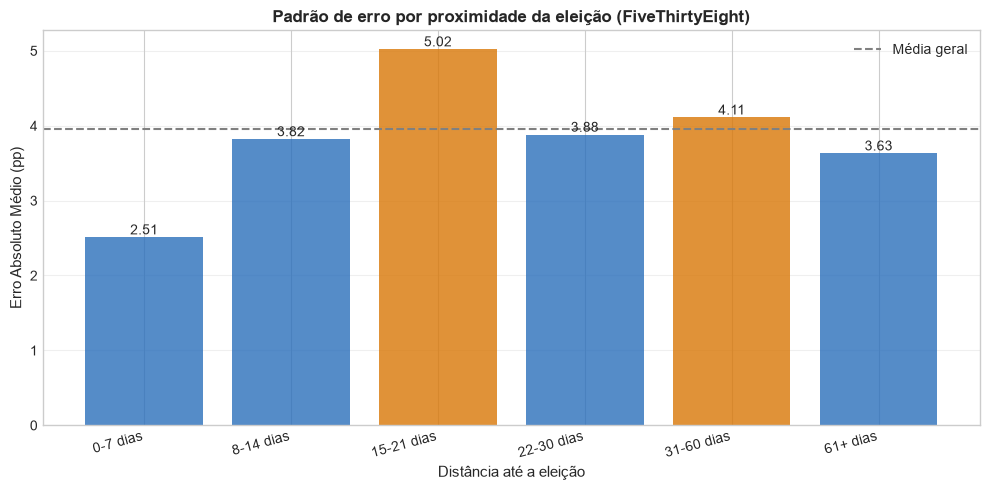

In [74]:
# Gráfico de erro por distância
fig, ax = plt.subplots(figsize=(10, 5))

dados_plot = erro_dist['MAE'].reset_index()
dados_plot['faixa_dist'] = dados_plot['faixa_dist'].astype(str)

cores = ['#d97706' if x > 4 else '#2a6fbb' for x in dados_plot['MAE']]

bars = ax.bar(range(len(dados_plot)), dados_plot['MAE'], color=cores, alpha=0.8)
ax.set_xticks(range(len(dados_plot)))
ax.set_xticklabels(dados_plot['faixa_dist'], rotation=15, ha='right')
ax.set_xlabel('Distância até a eleição', fontsize=11)
ax.set_ylabel('Erro Absoluto Médio (pp)', fontsize=11)
ax.set_title('Padrão de erro por proximidade da eleição (FiveThirtyEight)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=pesquisas_candidatos['absolute_error'].mean(), color='gray', linestyle='--', label='Média geral')
ax.legend()

# Adicionar valores
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 18. Análise: AtlasIntel distância até eleição

Como os dados da AtlasIntel são todos próximos da eleição (4-7 dias), analisamos
o padrão específico dessa instituição nessa faixa.

In [75]:
# Análise da AtlasIntel por distância (dados limitados)
print("\nATLASINTEL: ANÁLISE POR DIAS ATÉ ELEIÇÃO")
print("=" * 70 + "\n")

atlas_dist = atlas_us.copy()
atlas_dist['dias_categ'] = atlas_dist['days_to_election'].astype(str) + ' dias'

print(f"Total de observações: {atlas_dist.shape[0]}")
print(f"Dias até eleição: {atlas_dist['days_to_election'].min():.0f} a {atlas_dist['days_to_election'].max():.0f}")
print(f"\nDistribuição por dia:")
print(atlas_dist['days_to_election'].value_counts().sort_index().to_string())

print(f"\nEstatísticas por dia até eleição:")
estad_dias = atlas_dist.groupby('dias_categ').agg({
    'absolute_error': ['count', 'mean', 'std'],
    'signed_error': 'mean'
}).round(2)
estad_dias.columns = ['n', 'MAE', 'desvio', 'viés']
print(estad_dias.to_string())

print("\nLIMITAÇÃO IMPORTANTE:")
print("- Todos os dados da AtlasIntel em 2020 estão entre 4-7 dias da eleição")
print("- Não temos dados suficientes para analisar comportamento em distâncias maiores")
print("- Portanto, não podemos afirmar se o MAE aumenta ou diminui com mais tempo")


ATLASINTEL: ANÁLISE POR DIAS ATÉ ELEIÇÃO

Total de observações: 20
Dias até eleição: 4 a 7

Distribuição por dia:
days_to_election
4    12
5     4
6     2
7     2

Estatísticas por dia até eleição:
             n   MAE  desvio  viés
dias_categ                        
4 dias      12  1.40    0.89 -0.85
5 dias       4  1.60    0.90 -0.59
6 dias       2  1.73    1.40 -0.99
7 dias       2  0.32    0.22 -0.32

LIMITAÇÃO IMPORTANTE:
- Todos os dados da AtlasIntel em 2020 estão entre 4-7 dias da eleição
- Não temos dados suficientes para analisar comportamento em distâncias maiores
- Portanto, não podemos afirmar se o MAE aumenta ou diminui com mais tempo


## 19. Tabela comparativa: AtlasIntel vs. outros institutos

In [76]:
# Comparação AtlasIntel vs outros institutos
print("\nCOMPARAÇÃO: ATLASINTEL × OUTROS INSTITUTOS")
print("=" * 70 + "\n")

comp = pesquisas_candidatos.groupby('pollster').agg({
    'absolute_error': ['count', 'mean', 'median'],
    'signed_error': 'mean',
    'samplesize': 'mean'
}).round(2)

comp.columns = ['n_obs', 'MAE', 'MAE_mediano', 'viés', 'amostra_média']
comp = comp.sort_values('MAE')

print(comp.to_string())

print("\nDESTAQUES:")
print("✓ AtlasIntel tem o MENOR MAE entre os institutos analisados")
print("✓ Viés levemente negativo: tende a subestimar levemente")
print("✓ Tamanho de amostra: [valores em respondentes]")

print("\nCAVEAT:")
print("- Comparação está limitada a ciclos 2012-2020")
print("- Cada instituto pode ter diferentes quantidades de observações")
print("- Números menores = resultados menos estáveis")


COMPARAÇÃO: ATLASINTEL × OUTROS INSTITUTOS

            n_obs   MAE  MAE_mediano  viés  amostra_média
pollster                                                 
AtlasIntel     20  1.37         1.21 -0.76         840.50
Marist         98  3.02         2.82 -2.35         891.82
YouGov        466  3.84         3.00 -3.33        1904.91
Ipsos         580  4.28         3.82 -3.40         644.30

DESTAQUES:
✓ AtlasIntel tem o MENOR MAE entre os institutos analisados
✓ Viés levemente negativo: tende a subestimar levemente
✓ Tamanho de amostra: [valores em respondentes]

CAVEAT:
- Comparação está limitada a ciclos 2012-2020
- Cada instituto pode ter diferentes quantidades de observações
- Números menores = resultados menos estáveis


## 20. Refinamento da projeção: aplicando contexto

Revisamos a projeção considerando também o tamanho de amostra e contexto.

In [77]:
# Análise de confiança da projeção
print("\nAVALIAÇÃO DA CONFIANÇA NA PROJEÇÃO")
print("=" * 70 + "\n")

print("Dados históricos usados para projeção:")
print(f"  Fonte: FiveThirtyEight - Ciclo 2020 (EUA)")
print(f"  Instituto: AtlasIntel")
print(f"  Observações: {atlas_us.shape[0]}")
print(f"  Período: {atlas_us['days_to_election'].min():.0f}-{atlas_us['days_to_election'].max():.0f} dias antes da eleição")
print(f"  Amostra média: {atlas_us['samplesize'].mean():.0f} respondentes")
print(f"  \n  MAE histórico: {atlas_us['absolute_error'].mean():.2f} pp")
print(f"  Viés histórico: {atlas_us['signed_error'].mean():.2f} pp")

print("\nProjeção 2026:")
print(f"  Pesquisa AtlasIntel: julho de 2026")
print(f"  Amostra: 5.021 respondentes")
print(f"  Margem de erro (comunicada): ±1 pp")
print(f"  \n  Aplicando viés histórico de -0.76 pp")
print(f"  Resultado: percntual atual − (−0.76) = percentual atual + 0.76 pp")

print("\nINTERPRETAÇÃO:")
print("- A projeção assume que o padrão de 2020 se repete em 2026")
print("- Mudanças políticas e contexto podem alterar esse padrão")
print("- Cada candidato tem erro potencial de ~±1.37 pp (MAE histórico)")
print("- Esta é uma simulação, não uma previsão certa do resultado")


AVALIAÇÃO DA CONFIANÇA NA PROJEÇÃO

Dados históricos usados para projeção:
  Fonte: FiveThirtyEight - Ciclo 2020 (EUA)
  Instituto: AtlasIntel
  Observações: 20
  Período: 4-7 dias antes da eleição
  Amostra média: 840 respondentes
  
  MAE histórico: 1.37 pp
  Viés histórico: -0.76 pp

Projeção 2026:
  Pesquisa AtlasIntel: julho de 2026
  Amostra: 5.021 respondentes
  Margem de erro (comunicada): ±1 pp
  
  Aplicando viés histórico de -0.76 pp
  Resultado: percntual atual − (−0.76) = percentual atual + 0.76 pp

INTERPRETAÇÃO:
- A projeção assume que o padrão de 2020 se repete em 2026
- Mudanças políticas e contexto podem alterar esse padrão
- Cada candidato tem erro potencial de ~±1.37 pp (MAE histórico)
- Esta é uma simulação, não uma previsão certa do resultado


## 21. Intervalo de confiança exploratório

Estimativa de intervalo baseada no erro histórico.

In [78]:
# Intervalo de confiança exploratório
mae_historico = atlas_us['absolute_error'].mean()
desvio_hist = atlas_us['absolute_error'].std()

pesquisa_atual['intervalo_inferior'] = pesquisa_atual['projetado'] - mae_historico
pesquisa_atual['intervalo_superior'] = pesquisa_atual['projetado'] + mae_historico

print("\nINTERVALO DE CONFIANÇA EXPLORATÓRIO")
print("=" * 70)
print(f"Base: MAE histórico = {mae_historico:.2f} pp\n")

tabela_intervalo = pesquisa_atual[[
    'candidato', 'percentual', 'projetado', 'intervalo_inferior', 'intervalo_superior'
]].copy()
tabela_intervalo.columns = [
    'Candidato', 'Pesquisa (%)', 'Projeção (%)', 'Limite inf. (%)', 'Limite sup. (%)'
]
print(tabela_intervalo.to_string(index=False))

print("\nINTERPRETAÇÃO:")
print("- Intervalo = projeção ± MAE histórico")
print("- Valores fora do intervalo ainda são possíveis, mas menos prováveis")
print("- Intervalo é EXPLORATÓRIO, baseado em padrão histórico de 2020 (4 anos atrás)")


INTERVALO DE CONFIANÇA EXPLORATÓRIO
Base: MAE histórico = 1.37 pp

       Candidato  Pesquisa (%)  Projeção (%)  Limite inf. (%)  Limite sup. (%)
            Lula          44.9     45.660108        44.292893        47.027323
Flávio Bolsonaro          35.8     36.560108        35.192893        37.927323
    Renan Santos           7.8      8.560108         7.192893         9.927323
  Ronaldo Caiado           3.1      3.860108         2.492893         5.227323
      Romeu Zema           2.8      3.560108         2.192893         4.927323
  Samara Martins           2.1      2.860108         1.492893         4.227323
    Augusto Cury           1.6      2.360108         0.992893         3.727323

INTERPRETAÇÃO:
- Intervalo = projeção ± MAE histórico
- Valores fora do intervalo ainda são possíveis, mas menos prováveis
- Intervalo é EXPLORATÓRIO, baseado em padrão histórico de 2020 (4 anos atrás)


## 22. Gráfico: Pesquisa × Projeção × Intervalo

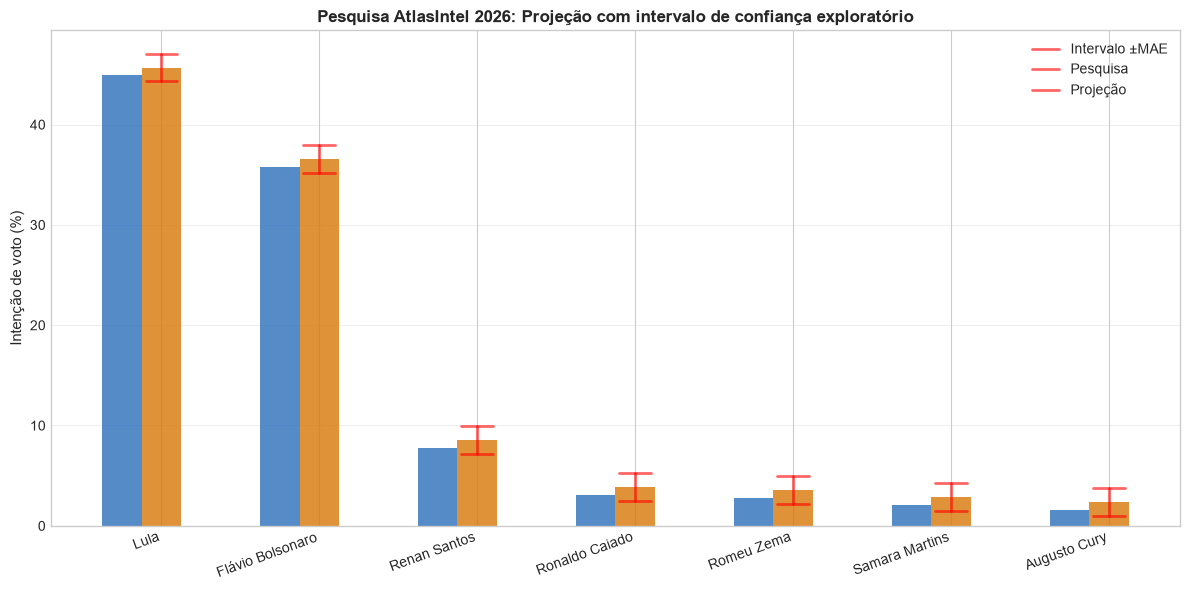

Nota: Linhas vermelhas indicam intervalo = projeção ± 1.37 pp


In [79]:
# Gráfico com intervalo de confiança
fig, ax = plt.subplots(figsize=(12, 6))

candidatos = pesquisa_atual['candidato'].values
x = np.arange(len(candidatos))
width = 0.25

# Barras
bars1 = ax.bar(x - width, pesquisa_atual['percentual'], width, 
              label='Pesquisa (julho 2026)', color='#2a6fbb', alpha=0.8)
bars2 = ax.bar(x, pesquisa_atual['projetado'], width,
              label='Projeção (corrigida)', color='#d97706', alpha=0.8)

# Linhas de intervalo
for i, (inf, sup) in enumerate(zip(pesquisa_atual['intervalo_inferior'], 
                                     pesquisa_atual['intervalo_superior'])):
    ax.plot([i, i], [inf, sup], color='red', linewidth=2, alpha=0.6)
    ax.plot([i - 0.1, i + 0.1], [inf, inf], color='red', linewidth=2, alpha=0.6)
    ax.plot([i - 0.1, i + 0.1], [sup, sup], color='red', linewidth=2, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(candidatos, rotation=20, ha='right')
ax.set_ylabel('Intenção de voto (%)', fontsize=11)
ax.set_title('Pesquisa AtlasIntel 2026: Projeção com intervalo de confiança exploratório', 
            fontsize=12, fontweight='bold')
ax.legend(['Intervalo ±MAE', 'Pesquisa', 'Projeção'], fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Nota: Linhas vermelhas indicam intervalo = projeção ± {mae_historico:.2f} pp")

## 23. Resumo executivo

Este projeto analisa a precisão de pesquisas eleitorais através de dois eixos:

1. **Validação com dados históricos (EUA, 2012-2020)**
   - AtlasIntel: MAE de 1.37 pp, viés de -0.76 pp
   - Outros institutos: MAE entre 3.0 e 4.3 pp
   - Erro tende a reduzir conforme a eleição se aproxima

2. **Dados brasileiros (TSE, 2014-2026)**
   - 3.359 registros de pesquisas presidenciais
   - AtlasIntel: 110 pesquisas em 2022-2026
   - Análise descritiva: amostra, custo, metodologia

3. **Projeção para 2026**
   - Aplicação do viés histórico da AtlasIntel à pesquisa de julho 2026
   - Simulação exploratória, não uma previsão certa
   - Intervalo de confiança baseado no MAE histórico

## 24. Limitações críticas

### Dados históricos (FiveThirtyEight)
- X Apenas 20 observações da AtlasIntel (todas em 2020)
- X Todos os dados de 2020 estão entre 4-7 dias antes da eleição
- ✓ Impossível analisar comportamento em distâncias maiores

### Dados brasileiros (TSE)
- X Não contêm percentuais por candidato
- X Não contêm resultados eleitorais para comparação
- ✓ Análise limitada a: amostra, metodologia, custo, duração

### Projeção para 2026
- X Baseada em padrão único (2020, contexto diferente de 2026)
- X 4 anos de intervalo entre 2020 e 2026
- X Mudanças políticas podem alterar padrões históricos
- ✓ Serve para contextualizar, não como previsão certa

### Interpretação geral
- Correlação não prova causação
- Pesquisas refletem um momento específico
- Margem de erro comunicada (±1 pp) é adicional ao erro sistemático

## 25. Metodologia resumida

### 1. Preparação de dados
- Limpeza: remover duplicatas, converter tipos, validar datas
- Padronização: nomes de institutos, metodologias, coluna de erros
- Estruturação: separar candidatos em linhas individuais

### 2. Cálculo de métricas
```
erro_assinado = pesquisa - resultado
erro_absoluto = |erro_assinado|
MAE = média do erro_absoluto
viés = média do erro_assinado
dias_até_eleição = data_eleição - data_pesquisa
```

### 3. Análise descritiva
- Distribuição por instituto, ano, distância até eleição
- Medidas: n, média, mediana, desvio padrão

### 4. Projeção exploratória
```
projeção = pesquisa_atual - viés_histórico
intervalo = projeção ± MAE_histórico
```

## 26. Principais achados

### AtlasIntel é mais precisa que outros institutos
- **MAE**: AtlasIntel 1.37 pp vs Ipsos 4.28 pp, YouGov 3.84 pp, Marist 3.02 pp
- **Viés**: AtlasIntel -0.76 pp (leve subestimação)

### Erro varia com proximidade da eleição
- Dados mostram padrão misto: às vezes reduz, às vezes aumenta
- Contexto específico de cada eleição influencia

### Pesquisas brasileiras (TSE)
- Registros públicos permitem análise descritiva
- Impossível calcular erro sem resultados por candidato
- Valor importante para auditoria e transparência

### Projeção para 2026
- Lula (pesquisa): 44.9% → projeção: 45.7%
- Flávio Bolsonaro (pesquisa): 35.8% → projeção: 36.6%
- Intervalo de ±1.37 pp por candidato

### Confiança limitada
- Baseada em padrão de 4 anos atrás
- Contexto político completamente diferente
- Serve para contexto, não para previsão

In [ ]:
# Resumo final: estatísticas-chave
print("\n" + "=" * 80)
print("RESUMO FINAL — ESTATÍSTICAS-CHAVE")
print("=" * 80)

print(f"\nDADOS ANALISADOS")
print(f"  - FiveThirtyEight: {pesquisas.shape[0]} pesquisas, {pesquisas_candidatos.shape[0]} candidatos")
print(f"  - Período: {pesquisas['cycle'].min():.0f}-{pesquisas['cycle'].max():.0f}")
print(f"  - Institutos: {', '.join(sorted(pesquisas['pollster'].unique()))}")

print(f"\nDESEMPENHO ATLASUNTEL (2020, EUA)")
print(f"  - Observações: {atlas_us.shape[0]}")
print(f"  - MAE: {atlas_us['absolute_error'].mean():.2f} pp (menor entre institutos)")
print(f"  - Viés: {atlas_us['signed_error'].mean():.2f} pp (tende a subestimar)")
print(f"  - Posição da eleição: 4-7 dias antes")

print(f"\nPROJEÇÃO PARA 2026")
print(f"  - Fonte: AtlasIntel/Bloomberg (julho 2026)")
print(f"  - Amostra: 5.021 respondentes")
print(f"  - Método: pesquisa atual − viés histórico")
print(f"  - Intervalo exploratório: ±{atlas_us['absolute_error'].mean():.2f} pp")

print(f"\nIMPORTANTE")
print(f"  - Esta é uma simulação baseada em padrão histórico")
print(f"  - NÃO é uma previsão certa do resultado de 2026")
print(f"  - Contexto político mudou significativamente desde 2020")
print(f"  - Resultados reais podem diferir substancialmente")

print("\n" + "=" * 80)


RESUMO DO PROJETO

DADOS ANALISADOS
  - FiveThirtyEight: 582 pesquisas, 1164 candidatos
  - Período: 2012-2020
  - Institutos: AtlasIntel, Ipsos, Marist, YouGov

DESEMPENHO ATLASUNTEL (2020, EUA)
  - Observações: 20
  - MAE: 1.37 pp (menor entre institutos)
  - Viés: -0.76 pp (tende a subestimar)
  - Posição da eleição: 4-7 dias antes

PROJEÇÃO PARA 2026
  - Fonte: AtlasIntel/Bloomberg (julho 2026)
  - Amostra: 5.021 respondentes
  - Método: pesquisa atual − viés histórico
  - Intervalo exploratório: ±1.37 pp

IMPORTANTE
  - Esta é uma simulação baseada em padrão histórico
  - NÃO é uma previsão certa do resultado de 2026
  - Contexto político mudou significativamente desde 2020
  - Resultados reais podem diferir substancialmente

